In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

from transformer_utils import (
    build_tf_datasets,
    compute_metrics_tf,
    evaluate_tf,
    plot_confusion_matrix_tf,
)

from utils import device_check

In [2]:
device = device_check()

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR  = NOTEBOOK_DIR.parent

SPLITS_DIR = PROJECT_DIR / 'data' / 'splits'
MODELS_DIR = PROJECT_DIR / 'models'

MAX_LENGTH = 128

# Two model names
DISTILBERT_NAME = 'distilbert-base-uncased'
ROBERTA_NAME    = 'roberta-base'

# Two tokenizers
tokenizer_distilbert = AutoTokenizer.from_pretrained(DISTILBERT_NAME)
tokenizer_roberta    = AutoTokenizer.from_pretrained(ROBERTA_NAME)

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


#Loading the datasets here again

In [3]:
# 1K dataset
test_1k = pd.read_csv(SPLITS_DIR / '1k_test.csv')
# 25K dataset
test_25k = pd.read_csv(SPLITS_DIR / '25k_test.csv')
# Video Game dataset
test_vg = pd.read_csv(SPLITS_DIR / 'vg_test.csv')
# Fixed VideoGame labels (1–5 → 0–4)
test_vg['Class'] = test_vg['Class'].astype(int) - 1

#building datasets

In [4]:
# ===== DISTILBERT DATASETS =====
datasets_1k_distil = build_tf_datasets(
    train_df=test_1k,
    val_df=test_1k,
    test_df=test_1k,
    tokenizer=tokenizer_distilbert,
    text_col='Sentence',
    label_col='Class',
    max_length=MAX_LENGTH,
)

datasets_25k_distil = build_tf_datasets(
    train_df=test_25k,
    val_df=test_25k,
    test_df=test_25k,
    tokenizer=tokenizer_distilbert,
    text_col='Sentence',
    label_col='Class',
    max_length=MAX_LENGTH,
)

datasets_vg_distil = build_tf_datasets(
    train_df=test_vg,
    val_df=test_vg,
    test_df=test_vg,
    tokenizer=tokenizer_distilbert,
    text_col='Sentence',
    label_col='Class',
    max_length=MAX_LENGTH,
)


# ===== ROBERTA DATASETS =====
datasets_1k_roberta = build_tf_datasets(
    train_df=test_1k,
    val_df=test_1k,
    test_df=test_1k,
    tokenizer=tokenizer_roberta,
    text_col='Sentence',
    label_col='Class',
    max_length=MAX_LENGTH,
)

datasets_25k_roberta = build_tf_datasets(
    train_df=test_25k,
    val_df=test_25k,
    test_df=test_25k,
    tokenizer=tokenizer_roberta,
    text_col='Sentence',
    label_col='Class',
    max_length=MAX_LENGTH,
)

datasets_vg_roberta = build_tf_datasets(
    train_df=test_vg,
    val_df=test_vg,
    test_df=test_vg,
    tokenizer=tokenizer_roberta,
    text_col='Sentence',
    label_col='Class',
    max_length=MAX_LENGTH,
)

#Laoded the trained models individually

In [5]:
# ===== DISTILBERT MODELS =====
model_1k_distil = AutoModelForSequenceClassification.from_pretrained(
    MODELS_DIR / 'distilbert_1k'
).to(device)

model_25k_distil = AutoModelForSequenceClassification.from_pretrained(
    MODELS_DIR / 'distilbert_25k'
).to(device)

model_vg_distil = AutoModelForSequenceClassification.from_pretrained(
    MODELS_DIR / 'distilbert_vg'
).to(device)


# ===== ROBERTA MODELS =====
model_1k_roberta = AutoModelForSequenceClassification.from_pretrained(
    MODELS_DIR / 'roberta_1k'
).to(device)

model_25k_roberta = AutoModelForSequenceClassification.from_pretrained(
    MODELS_DIR / 'roberta_25k'
).to(device)

model_vg_roberta = AutoModelForSequenceClassification.from_pretrained(
    MODELS_DIR / 'roberta_vg'
).to(device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

#Created trainer objects for our evaluation

In [6]:
from transformers import Trainer, TrainingArguments

def get_trainer(model):
    args = TrainingArguments(
        output_dir="tmp_eval",
        per_device_eval_batch_size=64,
        dataloader_num_workers=4,
        report_to="none",
    )

    return Trainer(
        model=model,
        args=args,
        compute_metrics=compute_metrics_tf,
    )

In [7]:
trainer_1k_distil = get_trainer(model_1k_distil)
trainer_25k_distil = get_trainer(model_25k_distil)
trainer_vg_distil = get_trainer(model_vg_distil)

trainer_1k_roberta = get_trainer(model_1k_roberta)
trainer_25k_roberta = get_trainer(model_25k_roberta)
trainer_vg_roberta = get_trainer(model_vg_roberta)

In [8]:
# ===== DISTILBERT =====
_, y_true_1k_d, y_pred_1k_d = evaluate_tf(trainer_1k_distil, datasets_1k_distil['test'], label='DistilBERT-1K', class_names=['Negative', 'Positive'])
_, y_true_25k_d, y_pred_25k_d = evaluate_tf(trainer_25k_distil, datasets_25k_distil['test'], label='DistilBERT-25K', class_names=['Negative', 'Positive'])
_, y_true_vg_d, y_pred_vg_d = evaluate_tf(trainer_vg_distil, datasets_vg_distil['test'], label='DistilBERT-VG', class_names=['1-star','2-star','3-star','4-star','5-star'])

# ===== ROBERTA =====
_, y_true_1k_r, y_pred_1k_r = evaluate_tf(trainer_1k_roberta, datasets_1k_roberta['test'], label='RoBERTa-1K', class_names=['Negative', 'Positive'])
_, y_true_25k_r, y_pred_25k_r = evaluate_tf(trainer_25k_roberta, datasets_25k_roberta['test'], label='RoBERTa-25K', class_names=['Negative', 'Positive'])
_, y_true_vg_r, y_pred_vg_r = evaluate_tf(trainer_vg_roberta, datasets_vg_roberta['test'], label='RoBERTa-VG', class_names=['1-star','2-star','3-star','4-star','5-star'])

Classification Report: DistilBERT-1K

              precision    recall  f1-score   support

    Negative      0.940     0.940     0.940        50
    Positive      0.940     0.940     0.940        50

    accuracy                          0.940       100
   macro avg      0.940     0.940     0.940       100
weighted avg      0.940     0.940     0.940       100

Trainer metrics:
  test_loss: 0.2186
  test_model_preparation_time: 0.0019
  test_accuracy: 0.9400
  test_macro_f1: 0.9400
  test_weighted_f1: 0.9400
  test_runtime: 0.6297
  test_samples_per_second: 158.8020
  test_steps_per_second: 3.1760


Classification Report: DistilBERT-25K

              precision    recall  f1-score   support

    Negative      0.908     0.917     0.912       988
    Positive      0.945     0.939     0.942      1512

    accuracy                          0.930      2500
   macro avg      0.927     0.928     0.927      2500
weighted avg      0.931     0.930     0.930      2500

Trainer metrics:
  test_loss: 0.1859
  test_model_preparation_time: 0.0016
  test_accuracy: 0.9304
  test_macro_f1: 0.9273
  test_weighted_f1: 0.9305
  test_runtime: 2.8838
  test_samples_per_second: 866.9020
  test_steps_per_second: 13.8700


Classification Report: DistilBERT-VG

              precision    recall  f1-score   support

      1-star      0.777     0.749     0.763     31181
      2-star      0.371     0.496     0.425     14131
      3-star      0.416     0.519     0.462     21230
      4-star      0.399     0.550     0.463     41225
      5-star      0.909     0.759     0.827    148587

    accuracy                          0.690    256354
   macro avg      0.574     0.615     0.588    256354
weighted avg      0.740     0.690     0.708    256354

Trainer metrics:
  test_loss: 0.9316
  test_model_preparation_time: 0.0022
  test_accuracy: 0.6900
  test_macro_f1: 0.5879
  test_weighted_f1: 0.7084
  test_runtime: 279.8214
  test_samples_per_second: 916.1340
  test_steps_per_second: 14.3160


Classification Report: RoBERTa-1K

              precision    recall  f1-score   support

    Negative      0.979     0.920     0.948        50
    Positive      0.925     0.980     0.951        50

    accuracy                          0.950       100
   macro avg      0.952     0.950     0.950       100
weighted avg      0.952     0.950     0.950       100

Trainer metrics:
  test_loss: 0.1891
  test_model_preparation_time: 0.0033
  test_accuracy: 0.9500
  test_macro_f1: 0.9500
  test_weighted_f1: 0.9500
  test_runtime: 0.4604
  test_samples_per_second: 217.1930
  test_steps_per_second: 4.3440


Classification Report: RoBERTa-25K

              precision    recall  f1-score   support

    Negative      0.928     0.930     0.929       988
    Positive      0.954     0.953     0.954      1512

    accuracy                          0.944      2500
   macro avg      0.941     0.942     0.941      2500
weighted avg      0.944     0.944     0.944      2500

Trainer metrics:
  test_loss: 0.1716
  test_model_preparation_time: 0.0043
  test_accuracy: 0.9440
  test_macro_f1: 0.9414
  test_weighted_f1: 0.9440
  test_runtime: 5.5050
  test_samples_per_second: 454.1340
  test_steps_per_second: 7.2660


Classification Report: RoBERTa-VG

              precision    recall  f1-score   support

      1-star      0.811     0.723     0.764     31181
      2-star      0.376     0.555     0.449     14131
      3-star      0.438     0.552     0.488     21230
      4-star      0.419     0.544     0.474     41225
      5-star      0.910     0.781     0.840    148587

    accuracy                          0.704    256354
   macro avg      0.591     0.631     0.603    256354
weighted avg      0.751     0.704     0.722    256354

Trainer metrics:
  test_loss: 0.9091
  test_model_preparation_time: 0.0033
  test_accuracy: 0.7043
  test_macro_f1: 0.6031
  test_weighted_f1: 0.7215
  test_runtime: 546.1792
  test_samples_per_second: 469.3590
  test_steps_per_second: 7.3350


#Comparison table

In [12]:
from sklearn.metrics import accuracy_score, f1_score

def compute_scores(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    return {
        "Model": name,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
    }

In [13]:
results = []

# DistilBERT
results.append(compute_scores("DistilBERT 1K", y_true_1k_d, y_pred_1k_d))
results.append(compute_scores("DistilBERT 25K", y_true_25k_d, y_pred_25k_d))
results.append(compute_scores("DistilBERT VG", y_true_vg_d, y_pred_vg_d))

# RoBERTa
results.append(compute_scores("RoBERTa 1K", y_true_1k_r, y_pred_1k_r))
results.append(compute_scores("RoBERTa 25K", y_true_25k_r, y_pred_25k_r))
results.append(compute_scores("RoBERTa VG", y_true_vg_r, y_pred_vg_r))

df_results = pd.DataFrame(results)
df_results

,Model,Accuracy,Macro F1,Weighted F1
0,DistilBERT 1K,0.940000,0.940000,0.940000
1,DistilBERT 25K,0.930400,0.927328,0.930460
2,DistilBERT VG,0.689972,0.587873,0.708387
3,RoBERTa 1K,0.950000,0.949955,0.949955
4,RoBERTa 25K,0.944000,0.941447,0.944010
5,RoBERTa VG,0.704284,0.603143,0.721504


Confusion matrices

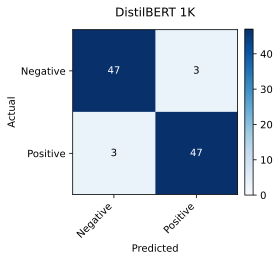

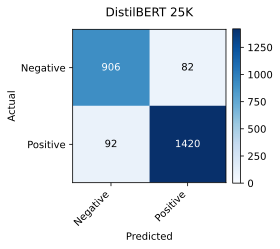

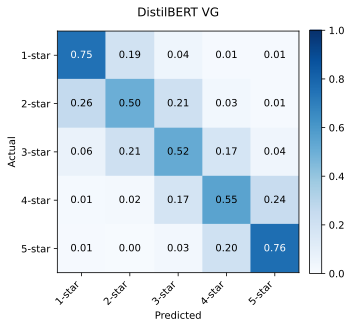

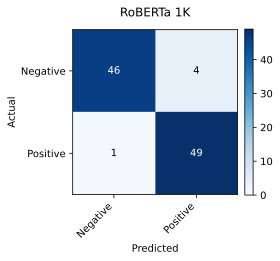

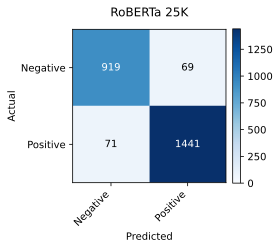

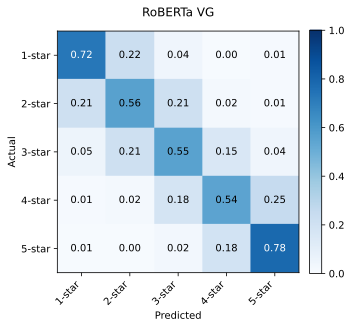

In [14]:
# ===== DISTILBERT =====
plot_confusion_matrix_tf(y_true_1k_d, y_pred_1k_d, 2, ['Negative','Positive'], 'DistilBERT 1K')
plot_confusion_matrix_tf(y_true_25k_d, y_pred_25k_d, 2, ['Negative','Positive'], 'DistilBERT 25K')
plot_confusion_matrix_tf(y_true_vg_d, y_pred_vg_d, 5, ['1-star','2-star','3-star','4-star','5-star'], 'DistilBERT VG', normalize=True)

# ===== ROBERTA =====
plot_confusion_matrix_tf(y_true_1k_r, y_pred_1k_r, 2, ['Negative','Positive'], 'RoBERTa 1K')
plot_confusion_matrix_tf(y_true_25k_r, y_pred_25k_r, 2, ['Negative','Positive'], 'RoBERTa 25K')
plot_confusion_matrix_tf(y_true_vg_r, y_pred_vg_r, 5, ['1-star','2-star','3-star','4-star','5-star'], 'RoBERTa VG', normalize=True)